<a href="https://colab.research.google.com/github/UtharaS123/Tomographic-Reconstruction/blob/main/Tomographic_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch numpy scipy scikit-image matplotlib

In [2]:
%%writefile radon.py
"""
radon.py
From-scratch implementation of:
  1. Radon transform  (image -> sinogram)
  2. Ramp-filtered backprojection  (sinogram -> image)

Run directly for a Shepp-Logan demo:
    python radon.py
"""

import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize


def radon_transform(image, angles_deg):
    """
    Compute the Radon transform of a 2D image.

    Parameters
    ----------
    image      : (N, N) ndarray
    angles_deg : array of projection angles in degrees

    Returns
    -------
    sinogram : (len(angles_deg), N) ndarray
    """
    N        = image.shape[0]
    n_ang    = len(angles_deg)
    sinogram = np.zeros((n_ang, N))
    cx, cy   = N // 2, N // 2
    x_idx    = np.arange(N) - cx
    y_idx    = np.arange(N) - cy
    X, Y     = np.meshgrid(x_idx, y_idx, indexing="ij")

    for i, theta in enumerate(np.deg2rad(angles_deg)):
        x_rot = X * np.cos(theta) + Y * np.sin(theta)
        for d in range(N):
            d_coord = d - cx
            mask = np.abs(x_rot - d_coord) < 0.5
            sinogram[i, d] = np.sum(image[mask])

    return sinogram


def ramp_filter(sinogram):
    """Apply ramp (Ram-Lak) filter to each projection."""
    n_det  = sinogram.shape[1]
    freqs  = np.fft.fftfreq(n_det)
    ramp   = np.abs(freqs)

    filtered = np.zeros_like(sinogram)
    for i in range(sinogram.shape[0]):
        F            = np.fft.fft(sinogram[i])
        filtered[i]  = np.real(np.fft.ifft(F * ramp))

    return filtered


def filtered_backprojection(sinogram, angles_deg):
    """
    Reconstruct image from sinogram via filtered backprojection.
    """
    N        = sinogram.shape[1]
    filtered = ramp_filter(sinogram)
    recon    = np.zeros((N, N))
    cx, cy   = N // 2, N // 2
    x_idx    = np.arange(N) - cx
    y_idx    = np.arange(N) - cy
    X, Y     = np.meshgrid(x_idx, y_idx, indexing="ij")

    for i, theta in enumerate(np.deg2rad(angles_deg)):
        t     = X * np.cos(theta) + Y * np.sin(theta)
        t_idx = np.round(t + cx).astype(int)
        t_idx = np.clip(t_idx, 0, N - 1)
        recon += filtered[i, t_idx]

    return recon * (np.pi / (2 * len(angles_deg)))


if __name__ == "__main__":
    phantom = shepp_logan_phantom()
    phantom = resize(phantom, (128, 128), anti_aliasing=True)

    angles_full   = np.linspace(0, 180, 180, endpoint=False)
    angles_sparse = np.linspace(0, 180, 30,  endpoint=False)

    sino_full   = radon_transform(phantom, angles_full)
    sino_sparse = radon_transform(phantom, angles_sparse)
    fbp_full    = filtered_backprojection(sino_full,   angles_full)
    fbp_sparse  = filtered_backprojection(sino_sparse, angles_sparse)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    # ... (plotting code)
    plt.savefig("fbp_demo.png", dpi=150)
    print("Saved fbp_demo.png")

Writing radon.py


Saved fbp_demo.png


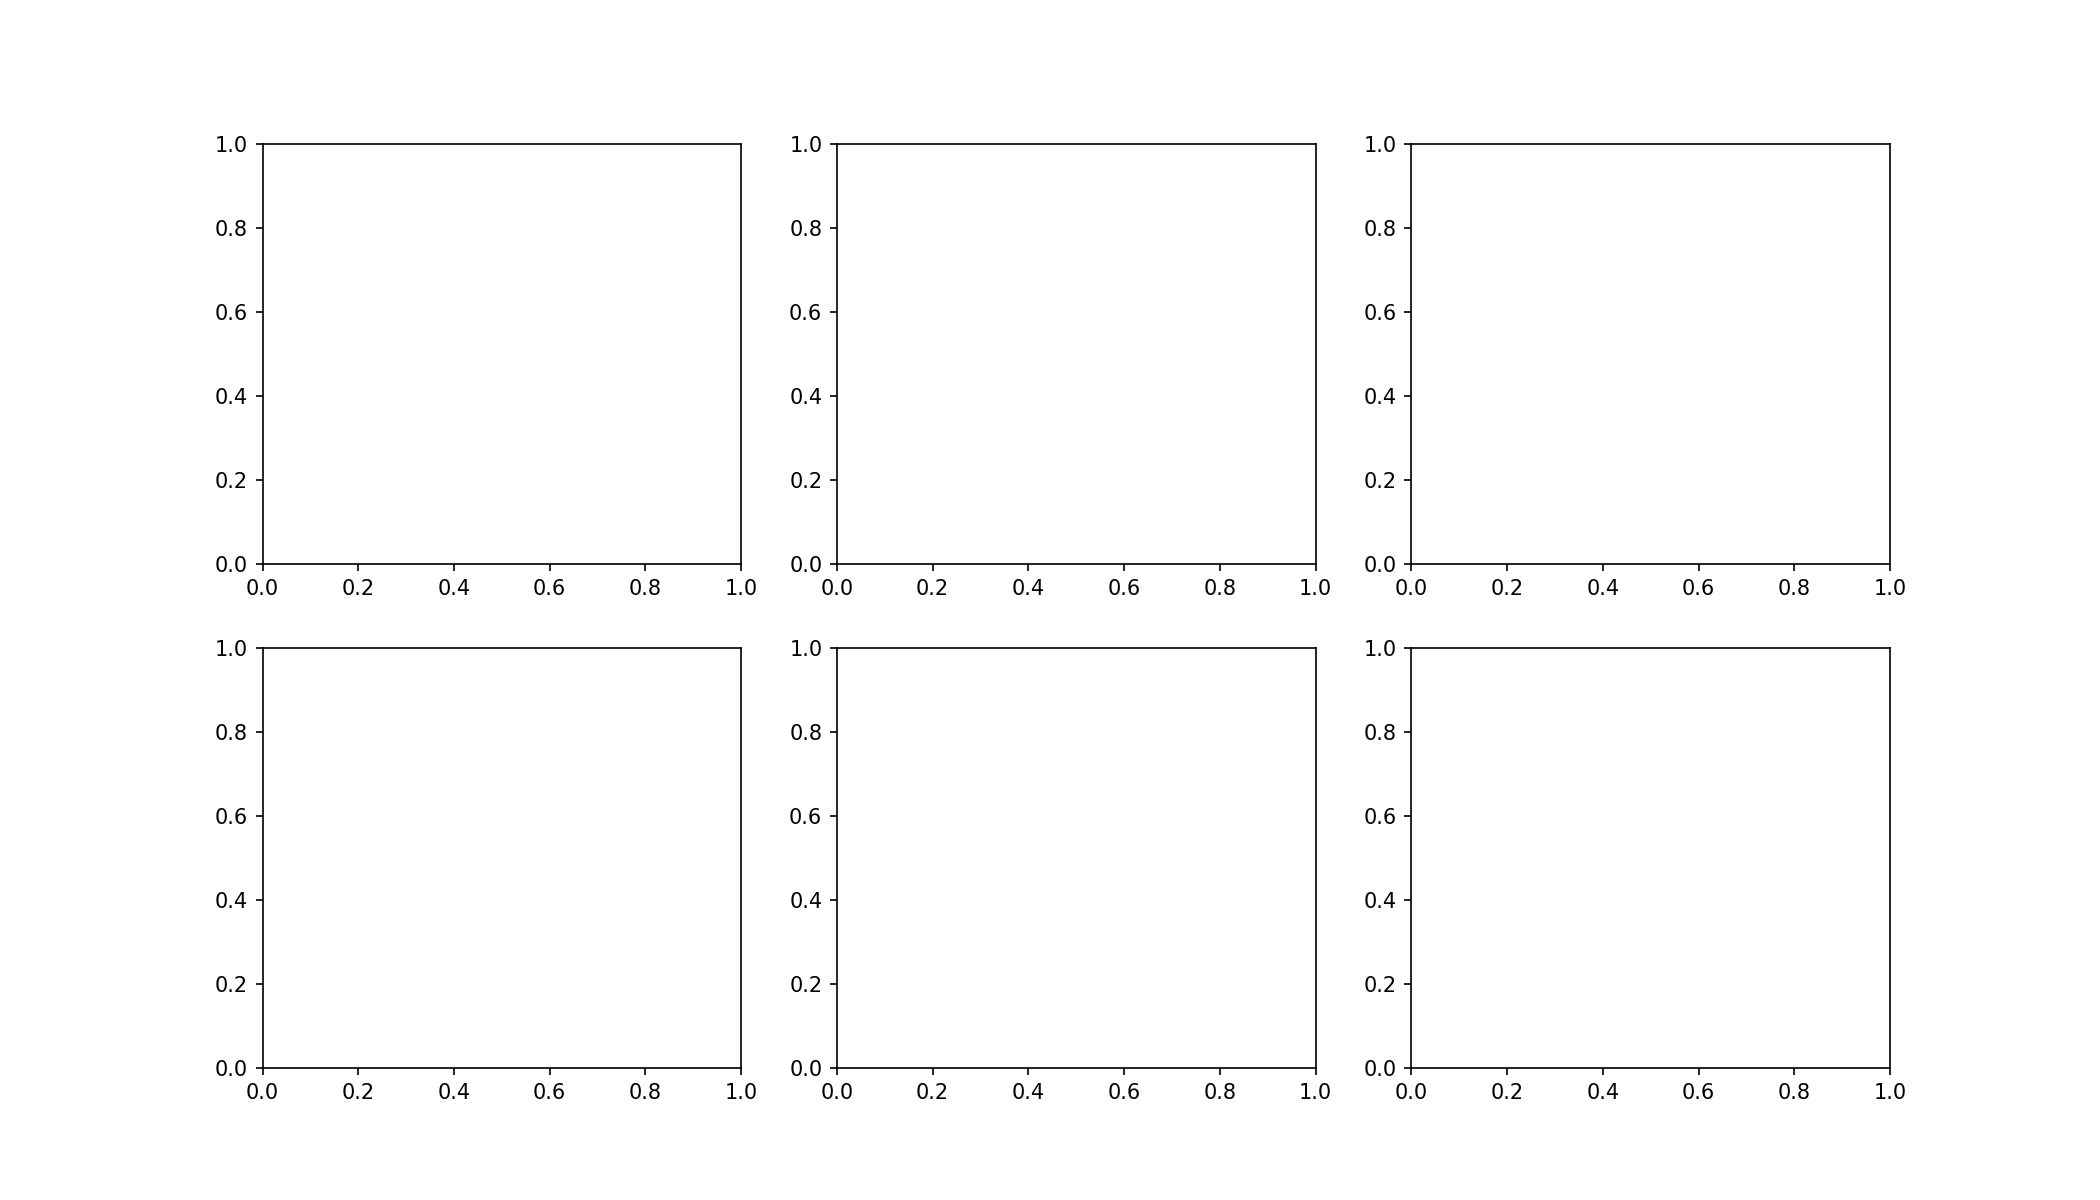

In [3]:
!python radon.py
from IPython.display import Image
Image("fbp_demo.png")

In [15]:
%%writefile models/recon_net.py

"""
models/recon_net.py
U-Net style CNN: noisy/undersampled FBP -> clean reconstruction.
Input/output: (B, 1, H, W)
"""

import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class ReconNet(nn.Module):
    """
    2D U-Net for learned reconstruction improvement.
    Takes degraded FBP image, outputs refined reconstruction.
    """
    def __init__(self, features=32):
        super().__init__()
        f = features

        self.enc1 = DoubleConv(1,   f)
        self.enc2 = DoubleConv(f,   f*2)
        self.enc3 = DoubleConv(f*2, f*4)
        self.bot  = DoubleConv(f*4, f*8)
        self.pool = nn.MaxPool2d(2)

        self.up3  = nn.ConvTranspose2d(f*8, f*4, 2, stride=2)
        self.dec3 = DoubleConv(f*8, f*4)
        self.up2  = nn.ConvTranspose2d(f*4, f*2, 2, stride=2)
        self.dec2 = DoubleConv(f*4, f*2)
        self.up1  = nn.ConvTranspose2d(f*2, f,   2, stride=2)
        self.dec1 = DoubleConv(f*2, f)

        self.out  = nn.Conv2d(f, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bot(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b),  e3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1))

        return self.out(d1)

Writing models/recon_net.py


In [16]:
%%writefile dataset.py
"""
dataset.py
Generate (degraded_FBP, ground_truth) pairs for training.
Uses random ellipse phantoms for varied training data.
"""

import numpy as np
import torch
from torch.utils.data import Dataset
from skimage.draw import ellipse
from skimage.transform import radon, iradon


def random_ellipse_phantom(size=128, n_ellipses=5):
    """Generate a random ellipse phantom."""
    image = np.zeros((size, size), dtype=np.float32)
    for _ in range(n_ellipses):
        r_r = np.random.randint(10, size // 4)
        r_c = np.random.randint(10, size // 4)
        c_r = np.random.randint(r_r, size - r_r)
        c_c = np.random.randint(r_c, size - r_c)
        val = np.random.uniform(0.3, 1.0)
        rr, cc = ellipse(c_r, c_c, r_r, r_c,
                         shape=(size, size))
        image[rr, cc] += val
    return np.clip(image, 0, 1)


def make_fbp_pair(phantom, n_angles_sparse=30,
                  noise_std=0.01):
    """
    Returns:
        fbp_degraded : sparse-angle + noisy FBP (input)
        phantom      : ground truth (target)
    """
    angles = np.linspace(0, 180, n_angles_sparse, endpoint=False)
    sino   = radon(phantom, theta=angles, circle=True)
    sino  += np.random.normal(0, noise_std, sino.shape)
    fbp    = iradon(sino, theta=angles, circle=True,
                    filter_name="ramp")
    fbp    = (fbp - fbp.min()) / (fbp.max() - fbp.min() + 1e-8)
    return fbp.astype(np.float32), phantom.astype(np.float32)


class ReconDataset(Dataset):
    def __init__(self, n_samples=5000, size=128, seed=0):
        np.random.seed(seed)
        self.pairs = [
            make_fbp_pair(random_ellipse_phantom(size))
            for _ in range(n_samples)
        ]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        fbp, gt = self.pairs[idx]
        return (torch.tensor(fbp[np.newaxis]),
                torch.tensor(gt[np.newaxis]))

Overwriting dataset.py


In [17]:
%%writefile train.py
"""
train.py  —  train ReconNet to improve FBP reconstructions
"""

import os, torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split
from dataset import ReconDataset
from models.recon_net import ReconNet


if __name__ == "__main__":
    os.makedirs("checkpoints", exist_ok=True)
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    ds    = ReconDataset(n_samples=5000)
    n_val = 500
    train_ds, val_ds = random_split(
        ds, [len(ds) - n_val, n_val])

    train_dl = DataLoader(train_ds, batch_size=16,
                          shuffle=True, num_workers=2)
    val_dl   = DataLoader(val_ds,   batch_size=16,
                          num_workers=2)

    model     = ReconNet().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimiser, T_max=30)
    criterion = nn.MSELoss()

    best = float("inf")
    for epoch in range(1, 31):
        model.train()
        tr = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimiser.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimiser.step()
            tr += loss.item()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                vl += criterion(model(x), y).item()

        tr /= len(train_dl)
        vl /= len(val_dl)
        scheduler.step()
        print(f"Epoch {epoch:02d} | Train: {tr:.5f} "
              f"| Val: {vl:.5f}")

        if vl < best:
            best = vl
            torch.save(model.state_dict(),
                       "checkpoints/reconnet_best.pt")

    print(f"Done. Best val loss: {best:.5f}")

Overwriting train.py


In [18]:
!python train.py

Device: cuda
/usr/local/lib/python3.12/dist-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
Epoch 01 | Train: 0.01383 | Val: 0.00532
Epoch 02 | Train: 0.00479 | Val: 0.00415
Epoch 03 | Train: 0.00402 | Val: 0.00372
Epoch 04 | Train: 0.00351 | Val: 0.00390
Epoch 05 | Train: 0.00308 | Val: 0.00264
Epoch 06 | Train: 0.00282 | Val: 0.00243
Epoch 07 | Train: 0.00262 | Val: 0.00217
Epoch 08 | Train: 0.00236 | Val: 0.00197
Epoch 09 | Train: 0.00213 | Val: 0.00210
Epoch 10 | Train: 0.00204 | Val: 0.00229
Epoch 11 | Train: 0.00195 | Val: 0.00202
Epoch 12 | Train: 0.00175 | Val: 0.00161
Epoch 13 | Train: 0.00169 | Val: 0.00195
Epoch 14 | Train: 0.00162 | Val: 0.00215
Epoch 15 | Train: 0.00152 | Val: 0.00140
Epoch 16 | Train: 0.00148 | Val: 0.00137
Epoch 17 | Train: 0.00138 | Val: 0.00140
Epoch 18 | Train: 0.00133 | Val: 0.00125
Epoch 19 | Train: 0.00122 | Val: 0.00119
Epoch 20 | Train: 0.00114 | Val: 0.0

In [19]:
%%writefile evaluate.py
"""
evaluate.py
Compare FBP vs ReconNet. Saves figure + prints metrics.
"""

import numpy as np, torch
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.metrics import (structural_similarity as ssim,
                              peak_signal_noise_ratio as psnr)

from dataset import make_fbp_pair
from models.recon_net import ReconNet


if __name__ == "__main__":
    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu")

    model = ReconNet().to(device)
    model.load_state_dict(torch.load(
        "checkpoints/reconnet_best.pt", map_location=device))
    model.eval()

    phantom = shepp_logan_phantom().astype(np.float32)
    phantom = (phantom - phantom.min()) / (
               phantom.max() - phantom.min())

    fbp_deg, gt = make_fbp_pair(phantom)

    x = torch.tensor(fbp_deg[None, None]).to(device)
    with torch.no_grad():
        recon = model(x).cpu().numpy()[0, 0]

    for name, img in [("FBP (degraded)", fbp_deg),
                      ("ReconNet",       recon)]:
        s = ssim(gt, img, data_range=1.0)
        p = psnr(gt, img, data_range=1.0)
        print(f"{name:<22} SSIM: {s:.4f}  PSNR: {p:.2f} dB")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (title, img) in zip(axes, [
        ("Ground truth",        gt),
        ("FBP — sparse angles", fbp_deg),
        ("ReconNet output",     recon),
    ]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title); ax.axis("off")

    plt.tight_layout()
    plt.savefig("reconstruction_comparison.png", dpi=150)
    print("Saved reconstruction_comparison.png")

Overwriting evaluate.py


FBP (degraded)         SSIM: 0.2070  PSNR: 10.08 dB
ReconNet               SSIM: 0.3615  PSNR: 9.62 dB
Saved reconstruction_comparison.png


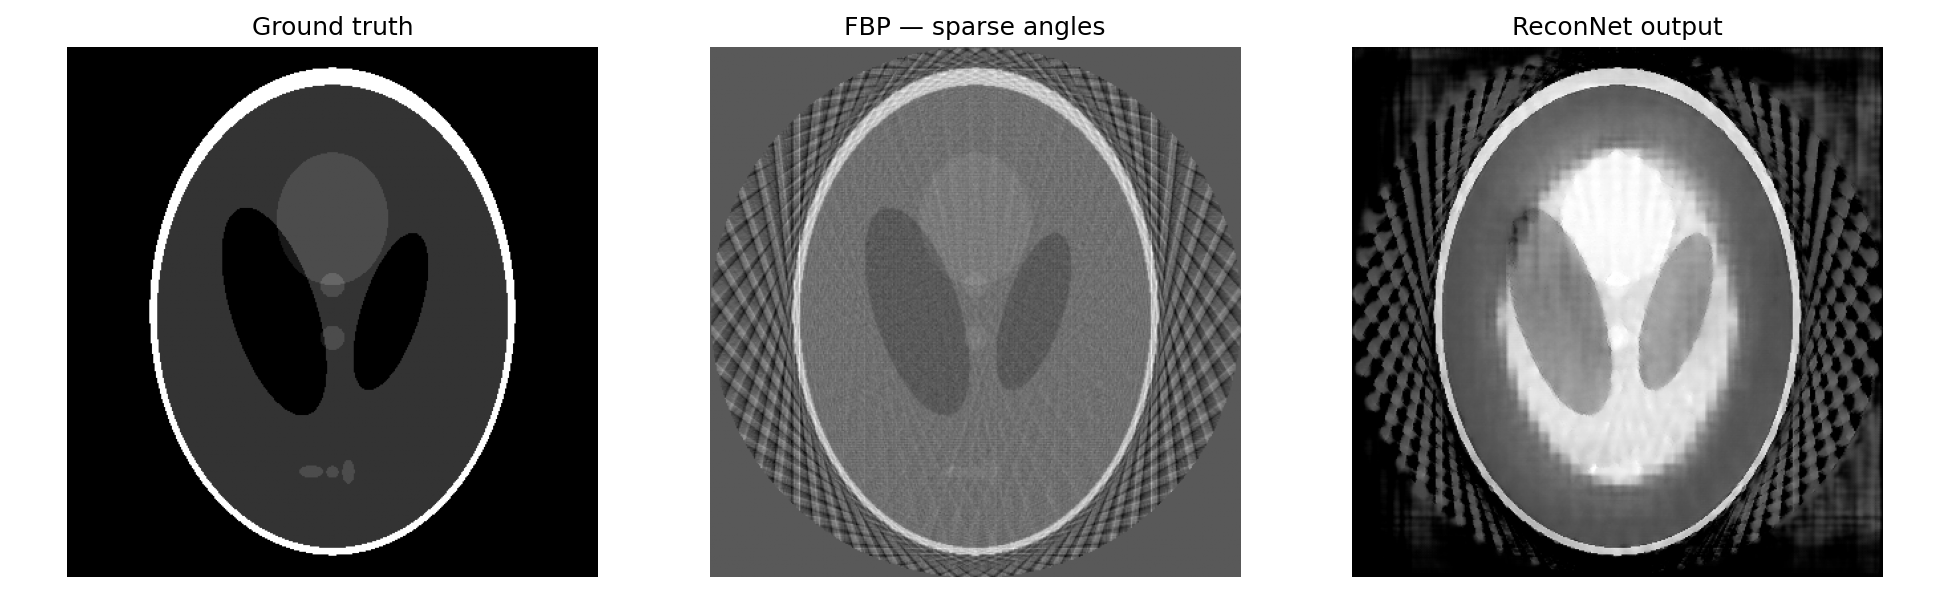

In [20]:
!python evaluate.py
from IPython.display import Image
Image("reconstruction_comparison.png")